# Introduction to Scikit-Learn(SKLearn).

This note demonstrates some of the most useful functions of the beautiful Scikit-Learn library.

What we're going to cover:

0. An end-to-end Scikit-Learn workflow
1. Getting the data ready
2. Choose the right estimator/algorithm for our problems
3. Fit the model/algorithm and use it to make predictions on our data
4. Evaluating a model
5. Improve a model
6. Save and load a trained model
7. Putting it all together!

# Standard imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [3]:
# Get ready data.
heart_disease = pd.read_csv("../Pandas/Data/heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 5. Improving a model


First predictions = baseline predictions. 
First model = baseline model.

From a data perspective:

* Could we collect more data? (generally, the more data, the better)
* Could we improve our data?

 From a model perspective:

* Is there a better model we could use?
* Could we improve the current model?

Hyperparameters vs. Parameters

* Parameters = model find these patterns in data
* Hyperparameters = settings on a model you can adjust to (potentially) improve its ability to find patterns

Three ways to adjust hyperparameters:

1. By hand
2. Randomly with RandomSearchCV
3. Exhaustively with GridSearchCV

In [4]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100)

In [5]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

## 5.1 Tuning hyperparameters by hand
Let's make 3 sets, training, validation and test.

We're going to try and adjust:

* max_depth
* max_features
* min_samples_leaf
* min_samples_split
* n_estimators

In [6]:
def evaluate_preds(y_true,y_preds):
    """
    Performs evaluation comparison on y_true vs y_preds labels on classification.
    """

    accuracy = accuracy_score(y_true,y_preds)
    precision = precision_score(y_true,y_preds)
    recall = recall_score(y_true,y_preds)
    f1 = f1_score(y_true,y_preds)
    metric_dict = {"accuracy":round(accuracy,2),
                  "precision":round(precision,2),
                  "recall": round(recall,2),
                  "f1": round(f1,2)}
    print(f"Acc: {accuracy * 100:.2f}%")
    print(f"precision: {precision *100:.2f}")
    print(f"Recall: {recall *100:.2f}")
    print(f"F1: {f1 *100:.2f}")

    return metric_dict

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Shuffle the data
heart_disease_shuffle =heart_disease.sample(frac=1)

# Split into X & y
X = heart_disease_shuffle.drop("target", axis=1)
y = heart_disease_shuffle["target"]

# Split the data into train, validation & test sets.
train_split = round(0.7 * len(heart_disease_shuffle)) # 70% data
valid_split = round( train_split + 0.15 * len(heart_disease_shuffle)) # 15% data
X_train,y_train = X[:train_split], y[:train_split]
X_valid, y_valid = X[train_split:valid_split], y[train_split:valid_split]
X_test,y_test = X[valid_split:], y[valid_split:]

clf = RandomForestClassifier()
clf.fit(X_train,y_train)

# Make baseline Prediction
y_preds = clf.predict(X_valid)

# Evaluate the classifier on validation set.
baseline_metrics = evaluate_preds(y_valid,y_preds)
baseline_metrics;

Acc: 82.22%
precision: 81.48
Recall: 88.00
F1: 84.62


In [8]:
np.random.seed(42)

# Create a second Classifier with different hyperparameters
clf_2 = RandomForestClassifier(n_estimators=100, max_depth=20)
clf_2.fit(X_train,y_train)

# Make Prediction with different hyperparameters
y_preds_2 = clf_2.predict(X_valid)

# Evaluate the 2nd classifier
clf_2_metrics = evaluate_preds(y_valid,y_preds_2)

Acc: 82.22%
precision: 84.00
Recall: 84.00
F1: 84.00


## 5.2 Hyperparameter tuning with RandomizedSearchCV

In [9]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split

grid = {"n_estimators": [10, 100, 200, 500, 1000, 1200],
       "max_depth": [None, 5, 10, 20, 30],
       "max_features": ["log2", "sqrt"],
       "min_samples_split": [2, 4, 6],
       "min_samples_leaf": [1, 2, 4]}

np.random.seed(42)

#split into X & y
X = heart_disease_shuffle.drop("target",axis=1)
y = heart_disease_shuffle["target"]

# Split into train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instanttiate RandomForestClassifier.
clf = RandomForestClassifier(n_jobs=1)

# Setup RandomizedSearchCV.
rs_clf = RandomizedSearchCV(estimator=clf,
                           param_distributions=grid,
                           n_iter=50, # Number of model to try.
                           cv=5,
                           verbose=2)
# Fit the RaRandomizedSearchCV version of clf
rs_clf.fit(X_train, y_train);

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.0s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.0s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.0s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   2.1s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.1s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.1s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=4, n_estimators=10

In [10]:
rs_clf.best_params_

{'n_estimators': 100,
 'min_samples_split': 6,
 'min_samples_leaf': 2,
 'max_features': 'log2',
 'max_depth': 5}

In [11]:
# Make Prediction with the best Hyperparameters
rs_y_preds = rs_clf.predict(X_test)

# Evaluate the predictions
rs_metrics = evaluate_preds(y_test,rs_y_preds)

# If the score doesn't improve increase the value of n_iter to 50

Acc: 81.97%
precision: 75.76
Recall: 89.29
F1: 81.97


## 5.3 Hyperparameter tuning with GridSearchCV

In [12]:
grid

{'n_estimators': [10, 100, 200, 500, 1000, 1200],
 'max_depth': [None, 5, 10, 20, 30],
 'max_features': ['log2', 'sqrt'],
 'min_samples_split': [2, 4, 6],
 'min_samples_leaf': [1, 2, 4]}

In [13]:
grid_2 = {'n_estimators': [100, 200, 500],
         'max_depth': [None],
         'max_features': ['log2', 'sqrt'],
         'min_samples_split': [6],
         'min_samples_leaf': [1, 2]}

In [14]:
from sklearn.model_selection import GridSearchCV, train_test_split

np.random.seed(42)

#split into X & y
X = heart_disease_shuffle.drop("target",axis=1)
y = heart_disease_shuffle["target"]

# Split into train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instanttiate RandomForestClassifier.
clf = RandomForestClassifier(n_jobs=1)

# Setup GridSearchCV.
gs_clf = GridSearchCV( estimator=clf,
                       param_grid=grid_2,
                       cv=5,
                       verbose=2)
# Fit the GridSearchCV version of clf
gs_clf.fit(X_train, y_train);

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, 

In [15]:
gs_clf.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 6,
 'n_estimators': 200}

In [16]:
gs_y_preds = gs_clf.predict(X_test)

# Evaluate the predictions
gs_metrics = evaluate_preds(y_test, gs_y_preds)

Acc: 78.69%
precision: 74.19
Recall: 82.14
F1: 77.97


##### Let's Compare our Different model metrics

<Axes: >

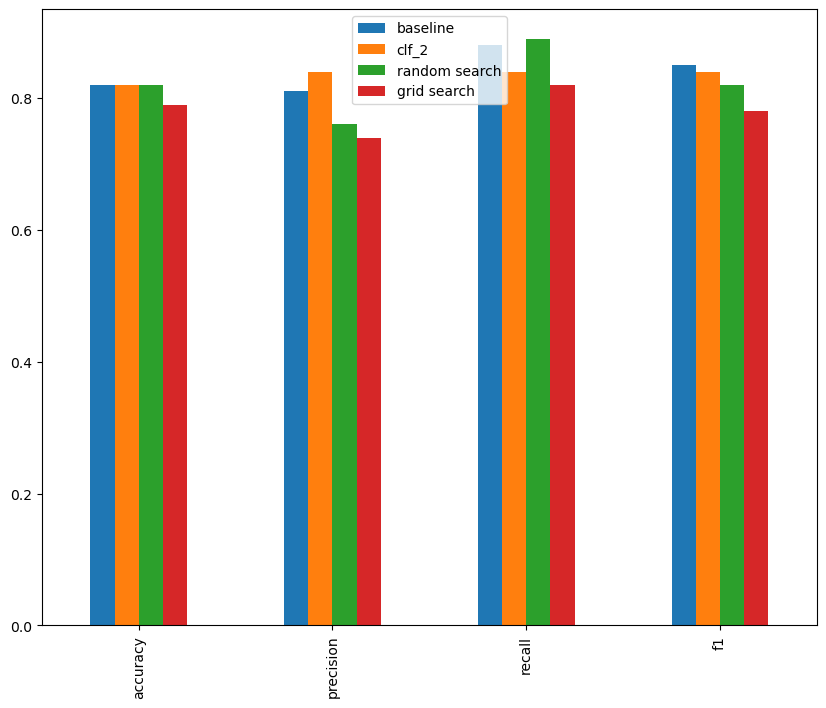

In [17]:
compare_metrics = pd.DataFrame({"baseline":baseline_metrics,
                               "clf_2":clf_2_metrics,
                               "random search":rs_metrics,
                               "grid search":gs_metrics})
compare_metrics.plot.bar(figsize=(10,8))

## 6. Saving and Loading trained machine learning model.

Two ways to save and load machine learning models.

1. With Python's pickle module.
2. with the joblib module

### Pickle

In [18]:
import pickle

# Save an existing model to file.
pickle.dump(gs_clf, open("gs_random_forest_model_1.pkl", "wb"))

In [19]:
# Load a saved model.
loaded_pickle_model = pickle.load(open("gs_random_forest_model_1.pkl", "rb"))

In [20]:
# Make some prediction
pickle_y_preds = loaded_pickle_model.predict(X_test)
evaluate_preds(y_test, pickle_y_preds)

Acc: 78.69%
precision: 74.19
Recall: 82.14
F1: 77.97


{'accuracy': 0.79, 'precision': 0.74, 'recall': 0.82, 'f1': 0.78}

### Joblib

In [22]:
from joblib import dump,load

# Save model to file
dump(gs_clf,filename="gs_random_forest_model_1.joblib")

['gs_random_forest_model_1.joblib']

In [24]:
# Import a saved joblib model.
loaded_joblib_model = load(filename="gs_random_forest_model_1.joblib")

In [25]:
# Make and evaluate joblib predictions
joblib_y_preds = loaded_joblib_model.predict(X_test)
evaluate_preds(y_test, joblib_y_preds)

Acc: 78.69%
precision: 74.19
Recall: 82.14
F1: 77.97


{'accuracy': 0.79, 'precision': 0.74, 'recall': 0.82, 'f1': 0.78}